# Fashion Trend Forecasting

#### Reason to work on this topic

Every few months a style that nobody seemed to care about is suddenly everywhere — on the street, on social media, in every shop window. By the time most people react it already feels a little bit over. The question I kept coming back to is simple: *"can you feel a trend coming before it peaks, and can the data feel it too?"* That is what this project tries to answer.

## The question

Given the recent history of a fashion style how often people search for it, what they say about it in reviews, and what it looks like - can we forecast whether it is rising or fading?

Why it matters in practice: retailers commit to orders months before the items hit the shelves, so a forecast that is even slightly better than "assume next month looks like this month" has real commercial value. And there is a sustainability angle too - buying into a style already past its peak produces unsold stock, which is a well-known problem in fashion.

We will sit in the middle between the two extremes: no expensive agency trend-forecasters, but also no opaque deep learning on runway imagery. Just transparent, from-scratch models whose math we can write down, validated against the naive baseline.

We treat the popularity of a style as a number $y_t \in [0, 100]$ sampled weekly (a Google-Trends-like index).

In [10]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

DATA = Path("data"); DATA.mkdir(exist_ok=True)
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

STYLES = [
    "oversized blazer", "wide-leg jeans", "cargo pants", "ballet flats",
    "puffer jacket", "slip dress", "trench coat", "chunky sneakers",
]
print(len(STYLES), "styles:", ", ".join(STYLES))

8 styles: oversized blazer, wide-leg jeans, cargo pants, ballet flats, puffer jacket, slip dress, trench coat, chunky sneakers


## 1. Style popularity time series

We model the weekly popularity index of each style $s$ over six years (312 weeks, 2021–2026) as an additive signal:

$$
y^{(s)}_t \;=\; b_s \;+\; m_s\, t \;+\; A_s \cos\!\Big(\tfrac{2\pi (t - \phi_s)}{52}\Big) \;+\; h_s\,\exp\!\Big(-\tfrac{(t-c_s)^2}{2 w_s^2}\Big) \;+\; \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma_s^2)
$$

clipped to $[0, 100]$. The four terms are: a base level $b_s$, a slope $m_s$ (positive = rising, negative = fading), a yearly season with amplitude $A_s$ and phase $\phi_s$, an optional viral fad bump, and noise. Because we choose all of these parameters ourselves, we know the ground-truth answer to "is this style rising?" and can later check whether the forecasts agree.

In [11]:
# slope is per-week, amp is the cosine amplitude, peak_week is the week of the year when the cosine peaks,
# fad is a tuple of (center_week, width, height) for the Gaussian fad component, and noise is the standard deviation of the Gaussian noise.
STYLE_PARAMS = {
    "oversized blazer": dict(base=40, slope=0.060, amp=8,  peak_week=8,  fad=(120, 14, 16), noise=3),
    "wide-leg jeans":   dict(base=33, slope=0.110, amp=6,  peak_week=2,  fad=None,           noise=3),
    "cargo pants":      dict(base=30, slope=0.045, amp=5,  peak_week=4,  fad=(150, 9,  26), noise=4),
    "ballet flats":     dict(base=45, slope=0.030, amp=7,  peak_week=14, fad=None,           noise=3),
    "puffer jacket":    dict(base=50, slope=0.000, amp=30, peak_week=50, fad=None,           noise=3),
    "slip dress":       dict(base=42, slope=-0.020, amp=22, peak_week=26, fad=None,          noise=3),
    "trench coat":      dict(base=48, slope=-0.050, amp=12, peak_week=40, fad=None,          noise=3),
    "chunky sneakers":  dict(base=56, slope=-0.080, amp=5,  peak_week=1,  fad=None,          noise=4),
}

N_WEEKS = 312          # 6 years: 2021–2026 inclusive
PERIOD = 52            # weeks per year

def generate_style_series(params: dict, n_weeks: int = N_WEEKS,
                          period: int = PERIOD, rng=rng) -> np.ndarray:
    '''Return one popularity series from the additive generative model.'''
    t = np.arange(n_weeks)
    trend = params["base"] + params["slope"] * t
    season = params["amp"] * np.cos(2 * np.pi * (t - params["peak_week"]) / period)
    fad = np.zeros(n_weeks)
    if params["fad"] is not None:
        c, w, h = params["fad"]
        fad = h * np.exp(-((t - c) ** 2) / (2 * w ** 2))
    noise = rng.normal(0, params["noise"], size=n_weeks)
    y = trend + season + fad + noise
    return np.clip(y, 0, 100)

dates = pd.date_range("2021-01-03", periods=N_WEEKS, freq="W")
trends = pd.DataFrame({s: generate_style_series(p) for s, p in STYLE_PARAMS.items()},
                      index=dates)
trends.index.name = "date"
trends.to_csv(DATA / "trends_synthetic.csv")
print("trends:", trends.shape)
print(f"date range from {trends.index[0].date()} to {trends.index[-1].date()}")
trends.head()

trends: (312, 8)
date range from 2021-01-03 to 2026-12-20


,oversized blazer,wide-leg jeans,cargo pants,ballet flats,puffer jacket,slip dress,trench coat,chunky sneakers
date,,,,,,,,
2021-01-03,45.458669,44.057454,36.311825,40.703650,78.613561,18.823881,47.597862,54.001532
2021-01-10,42.245029,40.383233,32.586272,44.766370,73.372338,20.560178,44.366904,60.989339
2021-01-17,48.359440,41.703965,33.298156,48.724625,79.465578,18.149555,43.260142,60.316323
2021-01-24,49.585565,38.396540,40.549115,49.363116,79.239894,17.929146,39.493026,58.741006
2021-01-31,41.470543,39.465288,31.017656,48.237063,70.064589,19.619304,45.734228,68.398786


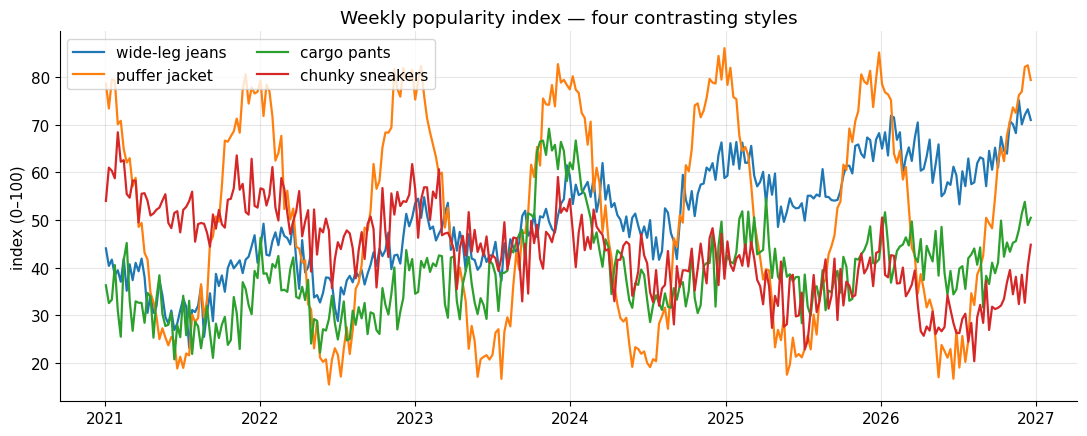

In [12]:
#  a riser, a winter-seasonal, a viral fad and a fader
show = ["wide-leg jeans", "puffer jacket", "cargo pants", "chunky sneakers"]
fig, ax = plt.subplots(figsize=(11, 4.5))
for s in show:
    ax.plot(trends.index, trends[s], label=s, linewidth=1.6)
ax.set_title("Weekly popularity index — four contrasting styles")
ax.set_ylabel("index (0–100)"); ax.legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

Already by eye you can read the model back out: wide-leg jeans climb steadily, the puffer jacket is flat on average but violently seasonal, cargo pants show a one-off viral spike, and chunky sneakers drift downward. Notebook 01 will try to recover exactly this structure without being told the parameters.

## 2. Customer reviews

For the language side we generate short product reviews from sentiment-laden word banks, so a bag-of-words model has real signal to learn. We deliberately inject 15% cross-talk (an occasional off-sentiment word) to make the problem non-trivial. A review's rating $r \in \{1,\dots,5\}$ is drawn from a per-style positivity probability; the binary sentiment target is 1 if $r \ge 4$ and 0 if $r \le 2$ (neutral $r=3$ rows are kept in the file).

In [13]:
POS_WORDS = ["love", "gorgeous", "flattering", "comfortable", "perfect", "stunning",
             "soft", "great quality", "obsessed", "compliments", "worth it", "beautiful"]
NEG_WORDS = ["disappointed", "cheap", "itchy", "poorly made", "too small", "returned",
             "awful", "flimsy", "overpriced", "shapeless", "scratchy", "regret"]
NEUTRAL_NOUNS = ["fabric", "fit", "color", "material", "stitching", "price",
                 "size", "length", "quality", "cut"]
POS_TEMPLATES = ["I {w} this {style}, the {n} is {w2}.",
                 "Absolutely {w} it — {n} exceeded my expectations.",
                 "This {style} is {w}; {n} feels {w2} and true to size."]
NEG_TEMPLATES = ["I am {w} with this {style}, the {n} is {w2}.",
                 "Honestly {w} — the {n} looks {w2} in person.",
                 "Would not buy this {style} again; {n} is {w2}."]

# Per-style probability that a given review is positive (drives both rating and text).
STYLE_POSITIVITY = {
    "oversized blazer": 0.80, "wide-leg jeans": 0.78, "cargo pants": 0.62,
    "ballet flats": 0.70, "puffer jacket": 0.75, "slip dress": 0.55,
    "trench coat": 0.72, "chunky sneakers": 0.50,
}

def make_review(style: str, positive: bool, rng=rng) -> str:
    bank, other = (POS_WORDS, NEG_WORDS) if positive else (NEG_WORDS, POS_WORDS)
    tmpl = rng.choice(POS_TEMPLATES if positive else NEG_TEMPLATES)
    w, w2 = rng.choice(bank, size=2, replace=True)
    n = rng.choice(NEUTRAL_NOUNS)
    text = tmpl.format(w=w, w2=w2, n=n, style=style)
    if rng.random() < 0.15:            # 15% cross-talk: sprinkle an off-sentiment word
        text += " Although the " + rng.choice(NEUTRAL_NOUNS) + " is " + rng.choice(other) + "."
    return text

def rating_from(positive: bool, rng=rng) -> int:
    if rng.random() < 0.12:            # 12% neutral 3-star reviews
        return 3
    return int(rng.integers(4, 6)) if positive else int(rng.integers(1, 3))

rows = []
N_PER_STYLE = 320
for style in STYLES:
    p = STYLE_POSITIVITY[style]
    for _ in range(N_PER_STYLE):
        positive = rng.random() < p
        r = rating_from(positive)
        rows.append((make_review(style, positive), r, style))

reviews = pd.DataFrame(rows, columns=["review_text", "rating", "style"])
reviews["sentiment"] = np.where(reviews["rating"] >= 4, 1,
                         np.where(reviews["rating"] <= 2, 0, -1))  # -1 = neutral/3-star
reviews = reviews.sample(frac=1, random_state=SEED).reset_index(drop=True)
reviews.to_csv(DATA / "reviews_synthetic.csv", index=False)
print("reviews:", reviews.shape)
reviews.head(6)

reviews: (2560, 4)


,review_text,rating,style,sentiment
0,This trench coat is worth it; size feels worth...,3,trench coat,-1
1,Honestly regret — the fabric looks regret in p...,1,slip dress,0
2,Absolutely stunning it — cut exceeded my expec...,4,ballet flats,1
3,"I worth it this wide-leg jeans, the cut is com...",4,wide-leg jeans,1
4,Would not buy this puffer jacket again; stitch...,2,puffer jacket,0
5,"I flattering this chunky sneakers, the stitchi...",4,chunky sneakers,1


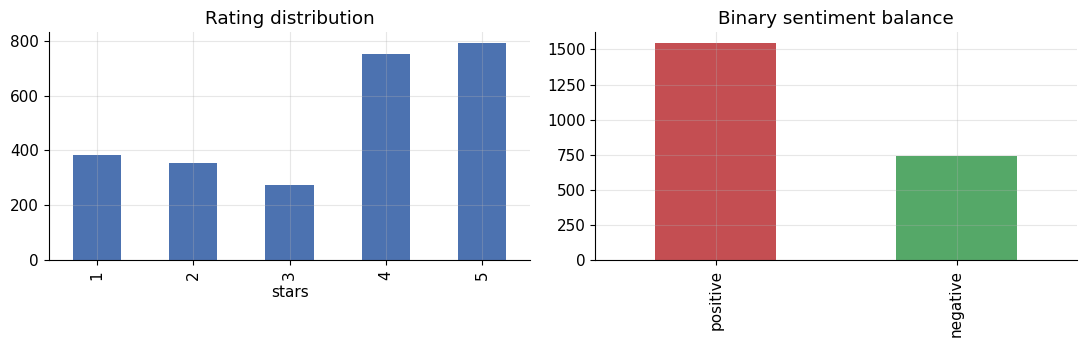

usable (non-neutral) reviews for classification: 2284


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
reviews["rating"].value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("Rating distribution"); ax[0].set_xlabel("stars")
binary = reviews[reviews.sentiment >= 0]
binary["sentiment"].map({0: "negative", 1: "positive"}).value_counts().plot.bar(
    ax=ax[1], color=["#C44E52", "#55A868"])
ax[1].set_title("Binary sentiment balance"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()
print("usable (non-neutral) reviews for classification:", len(binary))

## 3. Pattern types  

Styles are one axis of trend forecasting; the fabric patterns and prints people gravitate towards are another. A trench coat in plaid reads completely differently from one in solid beige, and the print itself can be trending independently of the garment silhouette.

We generate a weekly popularity index for eight common patterns using the same additive model as the styles. Each pattern has its own base level, slope, seasonal peak and - for the more volatile ones - a viral fad bump. This gives us a second signal table that travels alongside the style data and can be used for cross-signal analysis in notebook 05.

The eight patterns we track:
- floral - a perennial spring/summer driver with a recent upward nudge
- striped stable classic with mild seasonality
- plaid - autumn/winter dominant, slowly fading
- solid - the baseline; high popularity, very stable
- animal print - strongly rising, with a major viral moment mid-period
- geometric - mild riser, low seasonality
- tie-dye- peaked early in the period, now declining
- leopard - rising with a second viral bump later in the timeline

In [15]:
PATTERNS = [
    "floral", "striped", "plaid", "solid",
    "animal print", "geometric", "tie-dye", "leopard",
]

PATTERN_PARAMS = {
    "floral":       dict(base=45, slope=0.040, amp=12, peak_week=18, fad=(80,  10, 20), noise=3),
    "striped":      dict(base=50, slope=0.010, amp=5,  peak_week=1,  fad=None,           noise=2),
    "plaid":        dict(base=42, slope=-0.015, amp=10, peak_week=44, fad=None,          noise=3),
    "solid":        dict(base=60, slope=0.005, amp=4,  peak_week=1,  fad=None,           noise=2),
    "animal print": dict(base=35, slope=0.070, amp=6,  peak_week=10, fad=(200, 12, 22), noise=4),
    "geometric":    dict(base=38, slope=0.025, amp=5,  peak_week=5,  fad=None,           noise=3),
    "tie-dye":      dict(base=52, slope=-0.060, amp=7, peak_week=22, fad=(60,  8,  30), noise=4),
    "leopard":      dict(base=40, slope=0.055, amp=6,  peak_week=8,  fad=(255, 14, 18), noise=3),
}

patterns = pd.DataFrame(
    {p: generate_style_series(PATTERN_PARAMS[p]) for p in PATTERNS},
    index=dates,
)
patterns.index.name = "date"
patterns.to_csv(DATA / "patterns_synthetic.csv")
print("patterns_synthetic.csv:", patterns.shape)
patterns.head()

patterns_synthetic.csv: (312, 8)


,floral,striped,plaid,solid,animal print,geometric,tie-dye,leopard
date,,,,,,,,
2021-01-03,38.472150,55.572147,46.403557,66.745694,37.370994,42.653399,42.761170,40.029396
2021-01-10,38.596147,55.542627,51.032021,64.655791,38.966313,44.377195,42.781764,44.246798
2021-01-17,41.356815,53.205983,48.522870,60.171600,41.044352,47.568348,46.220499,45.290956
2021-01-24,39.503054,52.177726,44.073587,60.532510,32.461912,42.322171,46.673485,44.444707
2021-01-31,43.916461,54.210305,40.365942,63.955558,44.057401,41.882629,49.500826,46.720961


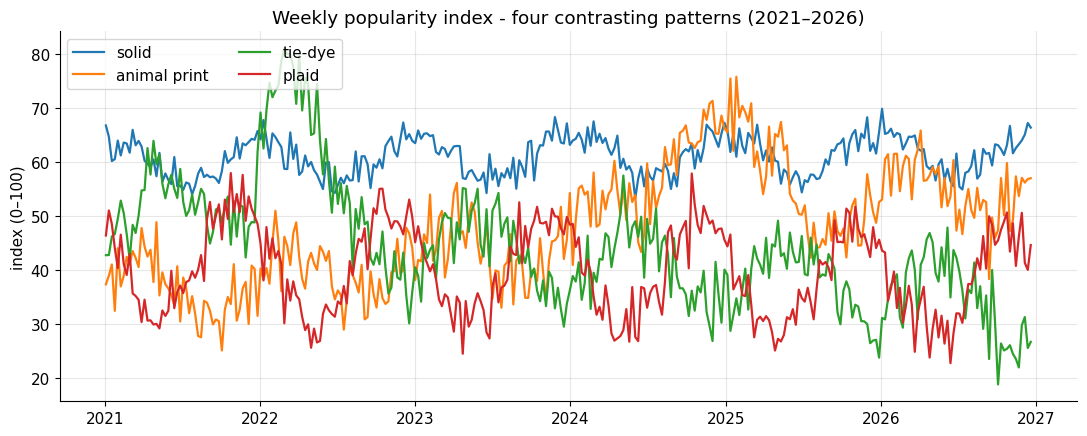

In [16]:
# Show four contrasting patterns: a stable classic, a riser with viral moment, an early fader and the seasonal one.
show_p = ["solid", "animal print", "tie-dye", "plaid"]
fig, ax = plt.subplots(figsize=(11, 4.5))
for p in show_p:
    ax.plot(patterns.index, patterns[p], label=p, linewidth=1.6)
ax.set_title("Weekly popularity index - four contrasting patterns (2021–2026)")
ax.set_ylabel("index (0–100)"); ax.legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

## 4. Garment images- Fashion-MNIST subset (real data)

For the computer-vision angle we use real images: a balanced subset of Fashion-MNIST — 6,000 training and 1,000 test grayscale $28\times28$ images across 10 garment classes.

images: (6000, 28, 28) labels: (6000,) classes: [np.str_('T-shirt/top'), np.str_('Trouser'), np.str_('Pullover'), np.str_('Dress'), np.str_('Coat'), np.str_('Sandal'), np.str_('Shirt'), np.str_('Sneaker'), np.str_('Bag'), np.str_('Ankle boot')]


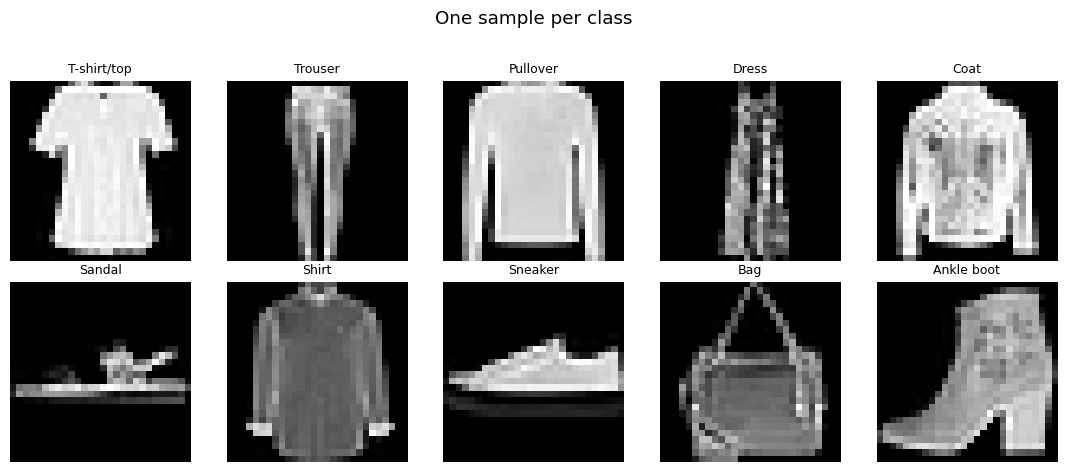

In [17]:
npz = np.load(DATA / "fashion_mnist_subset.npz", allow_pickle=True)
X_train, y_train = npz["X_train"], npz["y_train"]
X_test, y_test = npz["X_test"], npz["y_test"]
class_names = list(npz["class_names"])
print("images:", X_train.shape, "labels:", y_train.shape, "classes:", class_names)

fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for c, ax in enumerate(axes.ravel()):
    img = X_train[y_train == c][0]
    ax.imshow(img, cmap="gray"); ax.set_title(class_names[c], fontsize=9); ax.axis("off")
fig.suptitle("One sample per class", y=1.02)
plt.tight_layout(); plt.show()

## 5. EDA sanity checks

Before trusting any of this downstream, a few cheap assertions catch the obvious mistakes early — shapes are what we expect, no NaNs slipped through, all values are in valid ranges.

In [18]:
# Shapes and ranges are what we expect, and there are no missing values.
assert trends.shape == (N_WEEKS, len(STYLES)), "unexpected trends shape"
assert trends.isna().sum().sum() == 0, "NaNs in trends"
assert trends.values.min() >= 0 and trends.values.max() <= 100, "trends out of [0,100]"
assert patterns.shape == (N_WEEKS, len(PATTERNS)), "unexpected patterns shape"
assert patterns.isna().sum().sum() == 0, "NaNs in patterns"
assert patterns.values.min() >= 0 and patterns.values.max() <= 100, "patterns out of [0,100]"
assert set(reviews["sentiment"].unique()) <= {-1, 0, 1}
assert X_train.shape == (6000, 28, 28) and X_test.shape == (1000, 28, 28)
assert X_train.max() <= 255 and X_train.min() >= 0

print("all sanity checks")

display(trends.describe().round(1).T[["mean", "std", "min", "max"]])

all sanity checks


,mean,std,min,max
oversized blazer,51.1,8.7,31.6,73.7
wide-leg jeans,50.0,11.0,23.2,75.1
cargo pants,38.7,9.1,20.8,69.1
ballet flats,49.6,6.1,34.4,66.8
puffer jacket,49.9,21.4,15.5,86.0
slip dress,38.5,15.6,8.5,66.1
trench coat,40.0,9.4,19.5,61.1
chunky sneakers,43.5,9.2,20.4,68.4
